In [ ]:
import sys
sys.path.append('photon')
from photon.data import *


In [ ]:
pat_dir = "/workspace/DoseRAD2026Dev/data/DoseRAD2026/photon/training/1ABB006"
# pat_dir = 'photon/data/1ABB006'

plan = Plan(
    img_file_path=rf"{pat_dir}/image/ct.mha",
    info_json_path=rf"{pat_dir}/1ABB006.json",
    dose_dir=rf"{pat_dir}/dose",
)
print(plan.beam_info)

d = BeamData(plan)

State set to 0, 0
OrderedDict([(0, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, -28.13538836315937], 'n_mlc_leaf': 80, 'n_cp': 180}), (1, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, -8.135388363159374], 'n_mlc_leaf': 80, 'n_cp': 180}), (2, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, 11.864611636840626], 'n_mlc_leaf': 80, 'n_cp': 180})])


Reading dose files: 100%|██████████| 180/180 [00:09<00:00, 19.19it/s]


Starting parallel load with 8 threads...

Finished. Final array shape: (180, 246, 246, 249)
Data type: float16


Rotating dose & img: 100%|██████████| 6/6 [00:25<00:00,  4.22s/it]


Grid created


Calulating BEV beam path: 100%|██████████| 6/6 [00:07<00:00,  1.29s/it]


In [ ]:
len(d)

180

In [3]:
import matplotlib.pyplot as plt

In [7]:
d.plan.isocentre_ijk

(102, 139, 109)

In [11]:
d[0].shape

torch.Size([4, 245, 73, 35])

In [14]:
self = d
idx = 0
img = self.img_rot[idx]
bev = self.bev[idx]
dose = self.dose[idx]

mask = img > -1024
(zmin, ymin, xmin), (zmax, ymax, xmax) = get_bbox(bev.numpy(), margin=3)

data = torch.stack([
    img, bev, mask, dose
], dim=0)[:,zmin:zmax, ymin:ymax, xmin:xmax].moveaxis(2, 1)



In [20]:
img.shape

torch.Size([246, 246, 249])

(np.float64(-0.5), np.float64(248.5), np.float64(245.5), np.float64(-0.5))

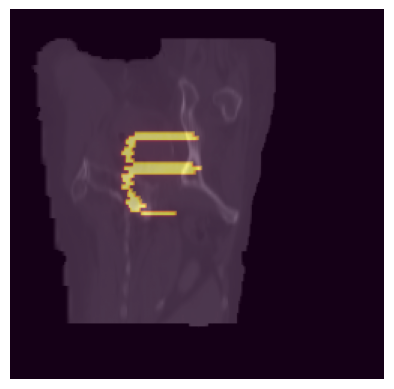

In [4]:
plt.imshow(d.img_rot[10][:, 139], cmap='gray')
plt.imshow(d.bev[10][:, 139], alpha=0.4)
plt.imshow(d.dose[10][:, 139], cmap='hot', alpha=0.3)
plt.axis('off')

(np.float64(-0.5), np.float64(248.5), np.float64(245.5), np.float64(-0.5))

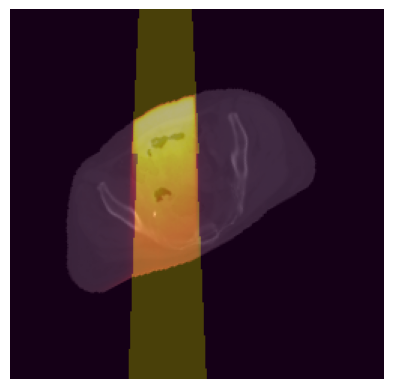

In [5]:
plt.imshow(d.img_rot[104][102], cmap='gray')
plt.imshow(d.bev[104][102], alpha=0.4)
plt.imshow(d.dose[104][102], cmap='hot', alpha=0.3)
plt.axis('off')

(np.float64(-0.5), np.float64(34.5), np.float64(72.5), np.float64(-0.5))

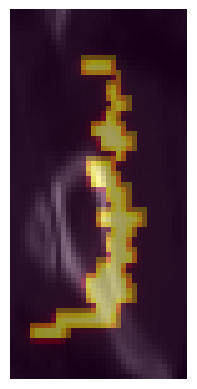

In [6]:
plt.imshow(d[0][0][140], cmap='gray')
plt.imshow(d[0][1][140], alpha=0.4)
plt.imshow(d[0][3][140], cmap='hot', alpha=0.3)
plt.axis('off')